In [9]:
import pandas as pd
import numpy as np
from datetime import datetime

In [10]:
df = pd.read_excel('fin_data_of_proj.xlsx')
df

,gara_id,application_name,author_id,builder_id,contractor_id,designer_id,engine_id,manager_id,status,decision_date,...,Коэффициент долговой нагрузки,Коэффициент долг на капитал,Коэффициент покрытия процентов,Покрытие долга,Target,life_cycle,today,real_life_cycle,percent_of_life_cycle,Target 2
0,729352,Заявка на гарантирование - 335,5.400012e+08,960340000376,9.603400e+11,0.000000e+00,2.210400e+11,1.904400e+11,NaN,NaT,...,1.0,0.060174,5.733126,3.488284,0,395,2024-11-01,729,1.845570,0
1,790750,Заявка на гарантирование - 334,4.044001e+10,960340000376,9.603400e+11,0.000000e+00,2.210400e+11,1.904400e+11,NaN,NaT,...,1.0,0.060174,5.733126,3.488284,0,639,2024-11-01,729,1.140845,0
2,845821,Заявка на гарантирование - 407,8.034001e+10,60340004172,6.034000e+10,0.000000e+00,1.304400e+11,2.109400e+11,NaN,NaT,...,1.0,0.929396,20.794199,0.550207,0,274,2024-11-01,508,1.854015,0
3,781580,Заявка на гарантирование - 379,5.114001e+10,981040003722,9.810400e+11,0.000000e+00,7.054001e+10,2.109400e+11,NaN,NaT,...,1.0,0.020449,1331.828571,5.548625,0,426,2024-11-01,742,1.741784,0
4,746713,Заявка на гарантирование - 373,9.207400e+11,80440009616,8.044001e+10,0.000000e+00,2.208400e+11,2.202400e+11,NaN,NaT,...,1.0,0.000000,inf,inf,0,275,2024-11-01,575,2.090909,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,91,NaN,1.054000e+10,110540015593,9.706400e+11,NaN,1.304400e+11,1.703400e+11,Завершенный,2020-02-14,...,1.0,0.138312,inf,7.945981,1,453,2024-11-01,1813,4.002208,0
218,84,NaN,NaN,50440002386,5.044000e+10,NaN,3.114000e+10,1.706400e+11,Завершенный,2021-06-28,...,1.0,0.024880,inf,1.897679,0,376,2024-11-01,1363,3.625000,0
219,111,NaN,6.074000e+10,60740002715,6.074000e+10,NaN,5.054001e+10,2.102400e+11,Завершенный,2021-04-27,...,1.0,NaN,inf,NaN,0,250,2024-11-01,1337,5.348000,0
220,2,NaN,3.114000e+10,111140016064,2.064000e+10,NaN,1.402400e+11,2.106400e+11,Завершенный,2022-02-24,...,1.0,0.000000,1.039538,inf,0,141,2024-11-01,1082,7.673759,0


In [11]:
# target_zero_df = df[df['Target'] == 0]

# rows_to_drop = target_zero_df.sample(frac=0.2, random_state=1).index

# df = df.drop(rows_to_drop)

## Feature Engeniring

In [12]:
# Unfin_cost and Season of every year

def get_season(date):
    month = date.month if pd.notnull(date) else None
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return None

df['season'] = df['dpg_date'].apply(get_season)
df['unfin_coff'] = df['unfin_cost']/df['cost_plan']

In [13]:
# Inflaction of every year 8%

annual_inflation_rate = 0.08
inflation_reference_date = datetime(2024, 11, 1)


df['dpg_date'] = pd.to_datetime(df['dpg_date'], errors='coerce')

financial_columns = [
    'cost_plan', 'flat_msprice', 'build_mscost', 'flat_mscost', 'com_msprice', 'park_price',
    'self_cost', 'unfin_cost', 'share_cost', 'warr_cost', 'comm_cost', 'cost_official',
    'Итого краткосрочные активы', 'Итого краткосрочных обязательств', 'Денежные средства',
    'Краткосрочная дебиторская задолженность', 'Запасы', 'Себестоимость', 'Доход от реализации',
    'Итого активы', 'Итого капитал', 'Итого пассивы', 'Краткосрочная кредиторская задолженность',
    'Операционная прибыль', 'Долгосрочные финансовые обязательства', 'Краткосрочные финансовые обязательства',
    'Итоговая прибыль (убыток)', 'Расходы на финансирование'
]

df['years_since_dpg'] = (inflation_reference_date - df['dpg_date']).dt.days / 365.25
df['inflation_factor'] = (1 + annual_inflation_rate) ** df['years_since_dpg']

for col in financial_columns:
    if col in df.columns:
        df[col] = df[col] * df['inflation_factor']

df.drop(columns=['years_since_dpg', 'inflation_factor'], inplace=True)


In [14]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df = df[:-11]
df = df.drop(columns=['application_name', 'author_id', 'engine_id', 'manager_id', 'status', 'decision_date',
                          'region_name', 'build_mscost', 'dpg_num_text', 'prolongation', 'update_date', 'state_id',
                          'create_date', 'annul_date', 'state_name', 'дата фин данных', 'life_cycle', 'today',
                          'real_life_cycle'])
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.drop('Target 2', axis = 1)
df = df.dropna(axis=1, how='all')

non_numeric_cols = df.select_dtypes(include=['object', 'datetime', 'timedelta']).columns

label_encoder = LabelEncoder()
for col in non_numeric_cols:
    df[col] = label_encoder.fit_transform(df[col].astype(str))

In [16]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [17]:
df

,gara_id,builder_id,contractor_id,designer_id,city_id,type,turn,network,period_month,start_date,...,Коэффициент финансового левериджа,Коэффициент финансовой независимости,Коэффициент долговой нагрузки,Коэффициент долг на капитал,Коэффициент покрытия процентов,Покрытие долга,Target,percent_of_life_cycle,season,unfin_coff
0,729352.0,9.603400e+11,9.603400e+11,0.0,18178.0,1.0,37.0,59.0,13.0,146.0,...,1.163885,0.859191,1.0,0.060174,5.733126,3.488284,0.0,1.845570,2.0,14.881747
1,790750.0,9.603400e+11,9.603400e+11,0.0,18178.0,1.0,40.0,60.0,21.0,146.0,...,1.163885,0.859191,1.0,0.060174,5.733126,3.488284,0.0,1.140845,2.0,0.143970
2,845821.0,6.034000e+10,6.034000e+10,0.0,18277.0,1.0,40.0,61.0,9.0,165.0,...,6.964214,0.143591,1.0,0.929396,20.794199,0.550207,0.0,1.854015,0.0,0.109875
3,781580.0,9.810400e+11,9.810400e+11,0.0,18267.0,1.0,40.0,59.0,14.0,144.0,...,3.248147,0.307868,1.0,0.020449,1331.828571,5.548625,0.0,1.741784,2.0,0.150448
4,746713.0,8.044001e+10,8.044001e+10,0.0,18194.0,1.0,33.0,60.0,10.0,160.0,...,1.252455,0.798432,1.0,0.000000,1.522332,0.155298,0.0,2.090909,2.0,0.210085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206,1152403.0,1.312400e+11,1.312400e+11,0.0,18178.0,1.0,40.0,60.0,12.0,181.0,...,2.829602,0.353407,1.0,0.000000,26.373242,0.155298,0.0,0.673973,1.0,0.145033
207,1130533.0,5.064001e+10,5.064001e+10,0.0,18277.0,1.0,40.0,60.0,10.0,178.0,...,2.561520,0.390393,1.0,0.331792,1.522332,0.823126,0.0,0.921311,1.0,0.104933
208,1124311.0,1.708400e+11,1.708400e+11,0.0,18194.0,1.0,42.0,60.0,23.0,177.0,...,6.597274,0.151578,1.0,5.479264,1.522332,-0.039945,0.0,0.462197,1.0,0.000000
209,1159397.0,3.104000e+10,3.104000e+10,0.0,18274.0,1.0,40.0,59.0,10.0,184.0,...,1.807297,0.553313,1.0,0.000000,1.522332,0.155298,0.0,0.601974,1.0,0.000000


SVM Accuracy: 0.89
SVM Confusion Matrix:
[[66  0]
 [ 8  0]]

SVM ROC AUC: 0.24

LogisticRegression Accuracy: 0.88
LogisticRegression Confusion Matrix:
[[60  6]
 [ 3  5]]

LogisticRegression ROC AUC: 0.68

Random Forest Accuracy: 0.91
Random Forest Confusion Matrix:
[[66  0]
 [ 7  1]]

Random Forest ROC AUC: 0.82

Gradient Boosting Accuracy: 0.89
Gradient Boosting Confusion Matrix:
[[63  3]
 [ 5  3]]

Gradient Boosting ROC AUC: 0.71



/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Accuracy: 0.81
AdaBoost Confusion Matrix:
[[58  8]
 [ 6  2]]

AdaBoost ROC AUC: 0.73

Bagging Accuracy: 0.91
Bagging Confusion Matrix:
[[65  1]
 [ 6  2]]

Bagging ROC AUC: 0.76



/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [06:46:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Accuracy: 0.89
XGBoost Confusion Matrix:
[[63  3]
 [ 5  3]]

XGBoost ROC AUC: 0.78



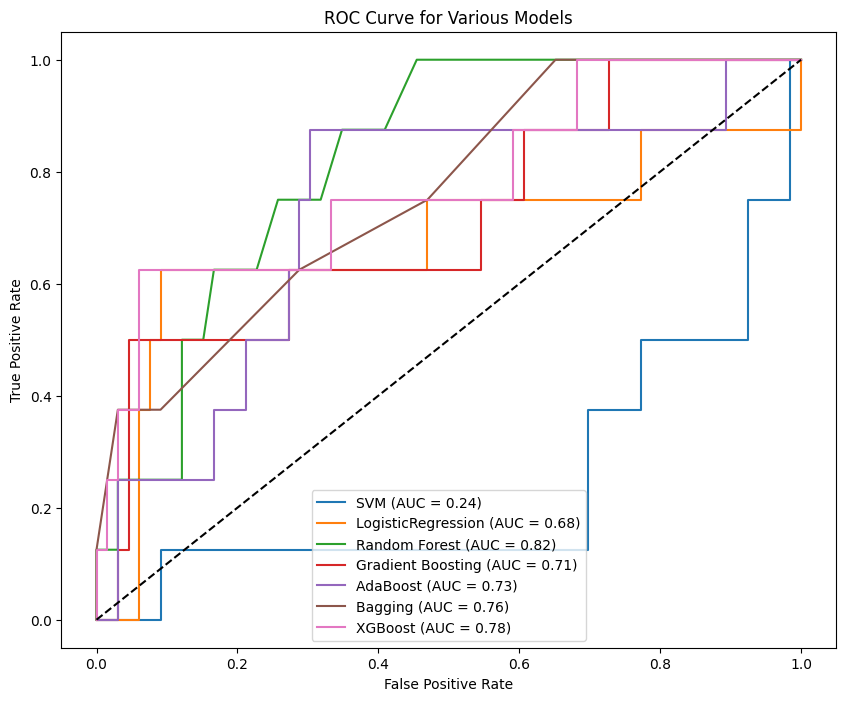

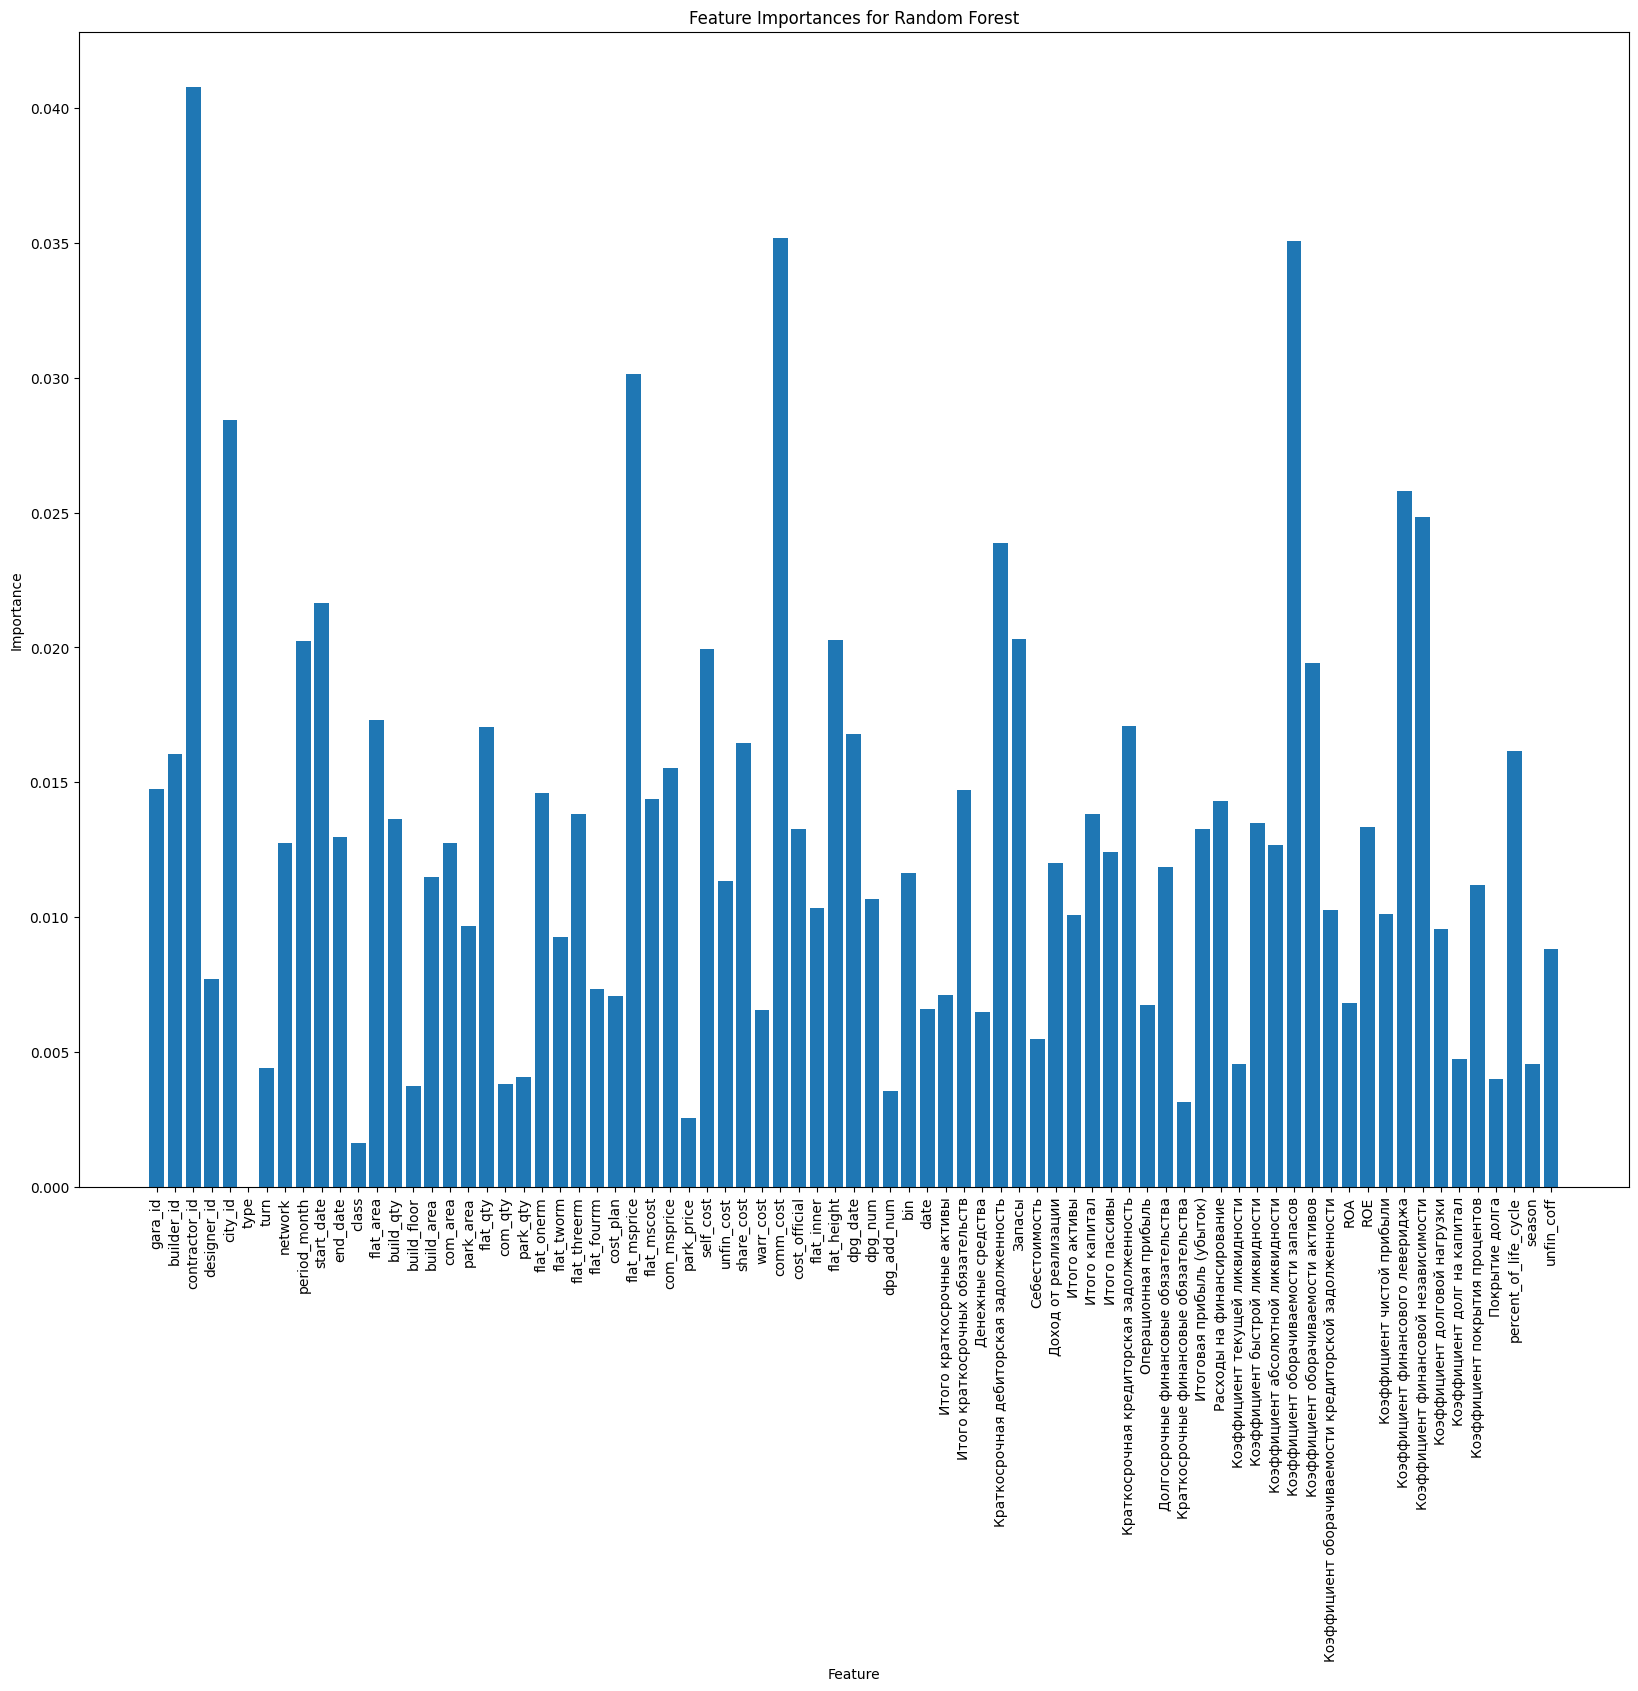

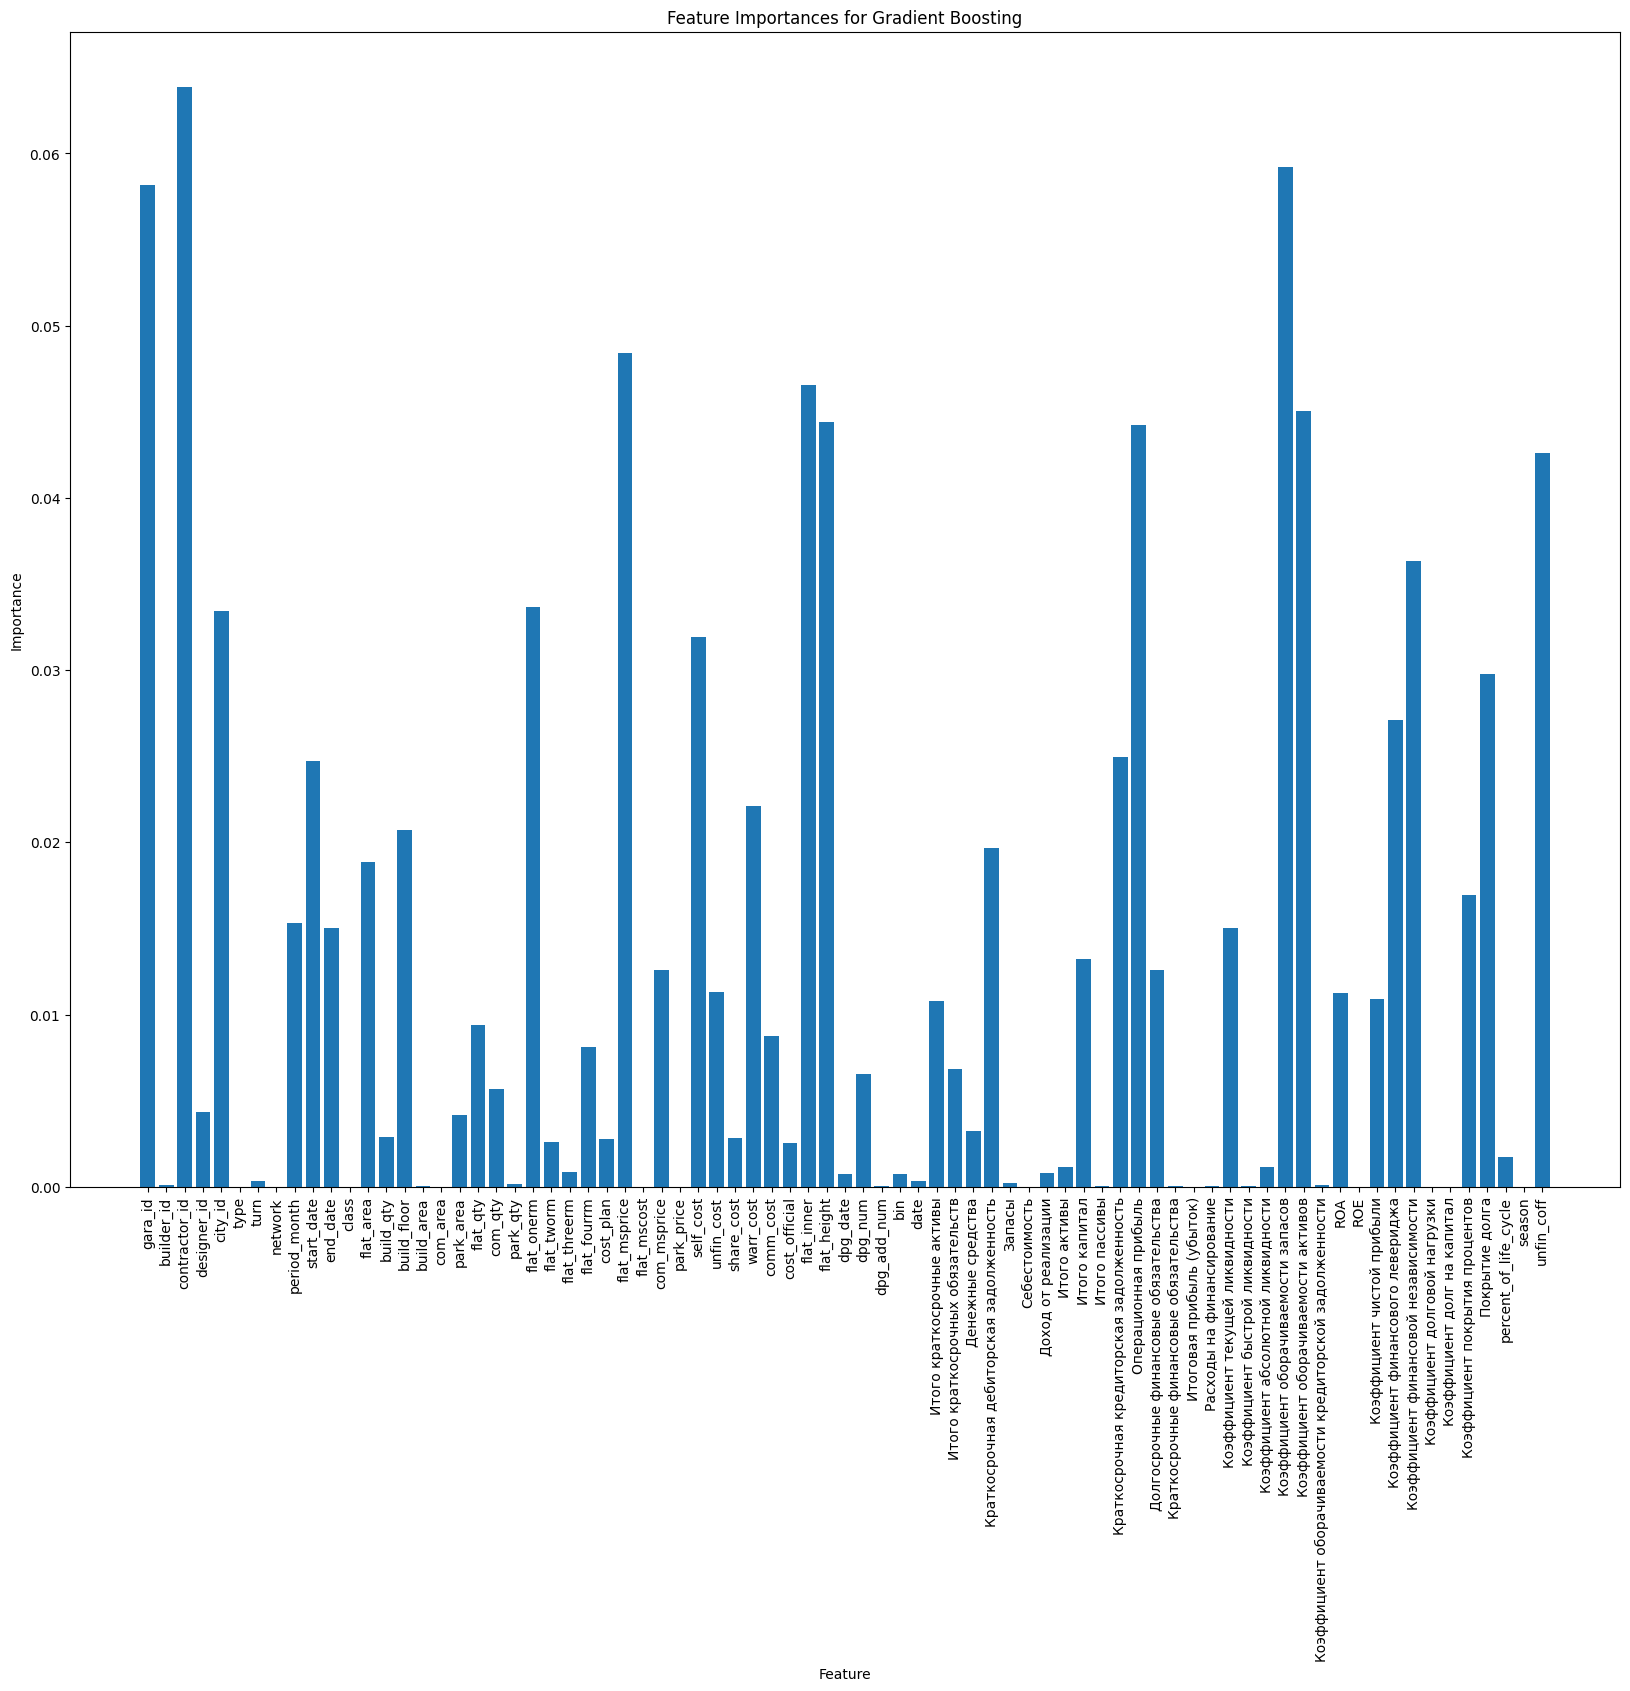

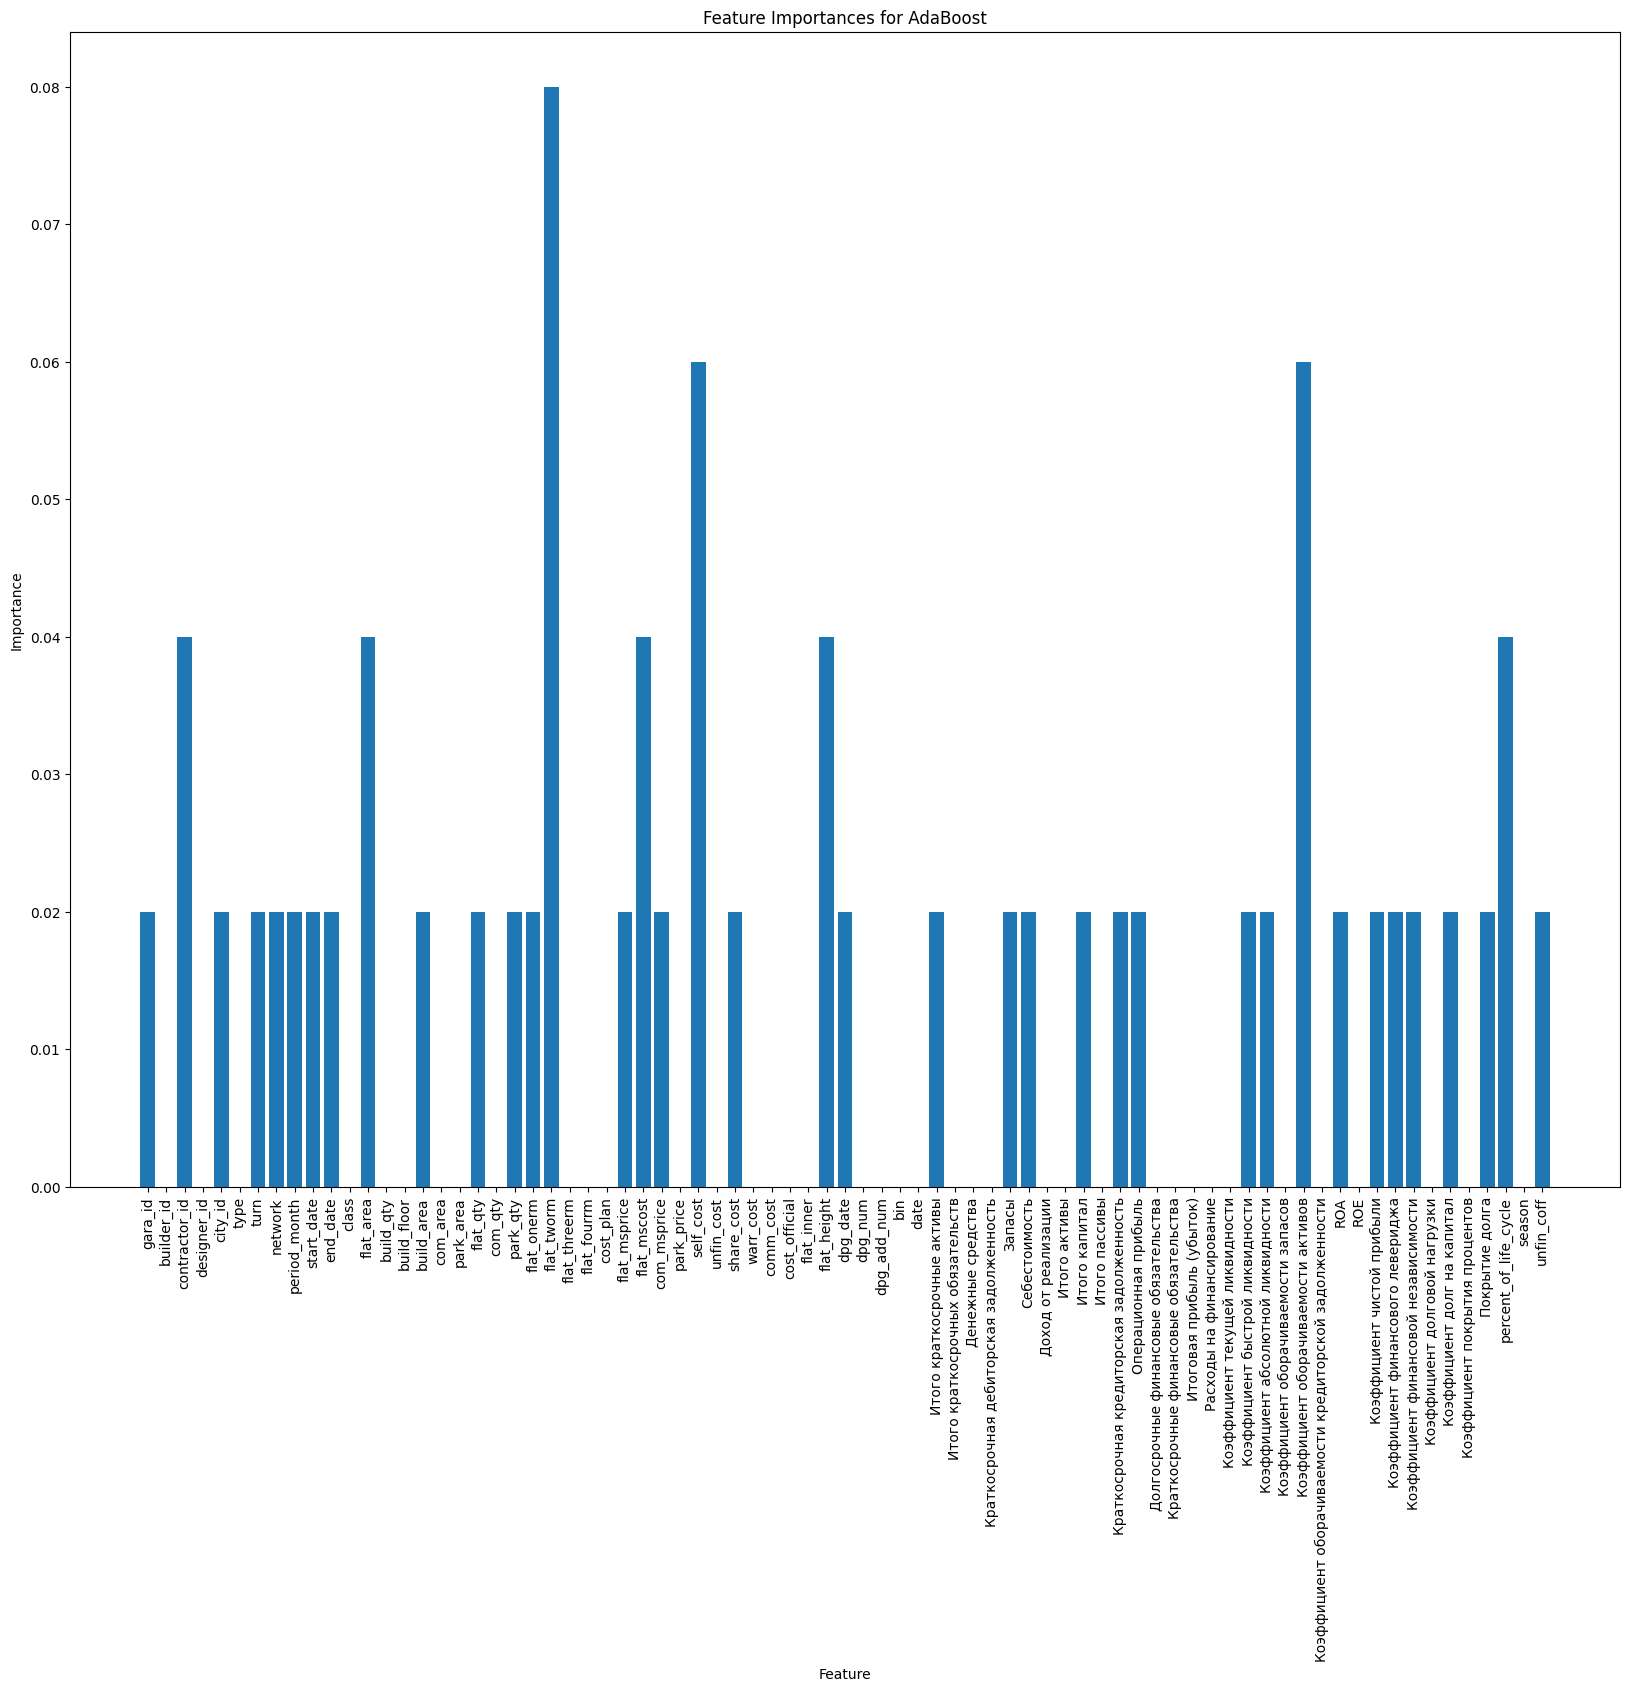

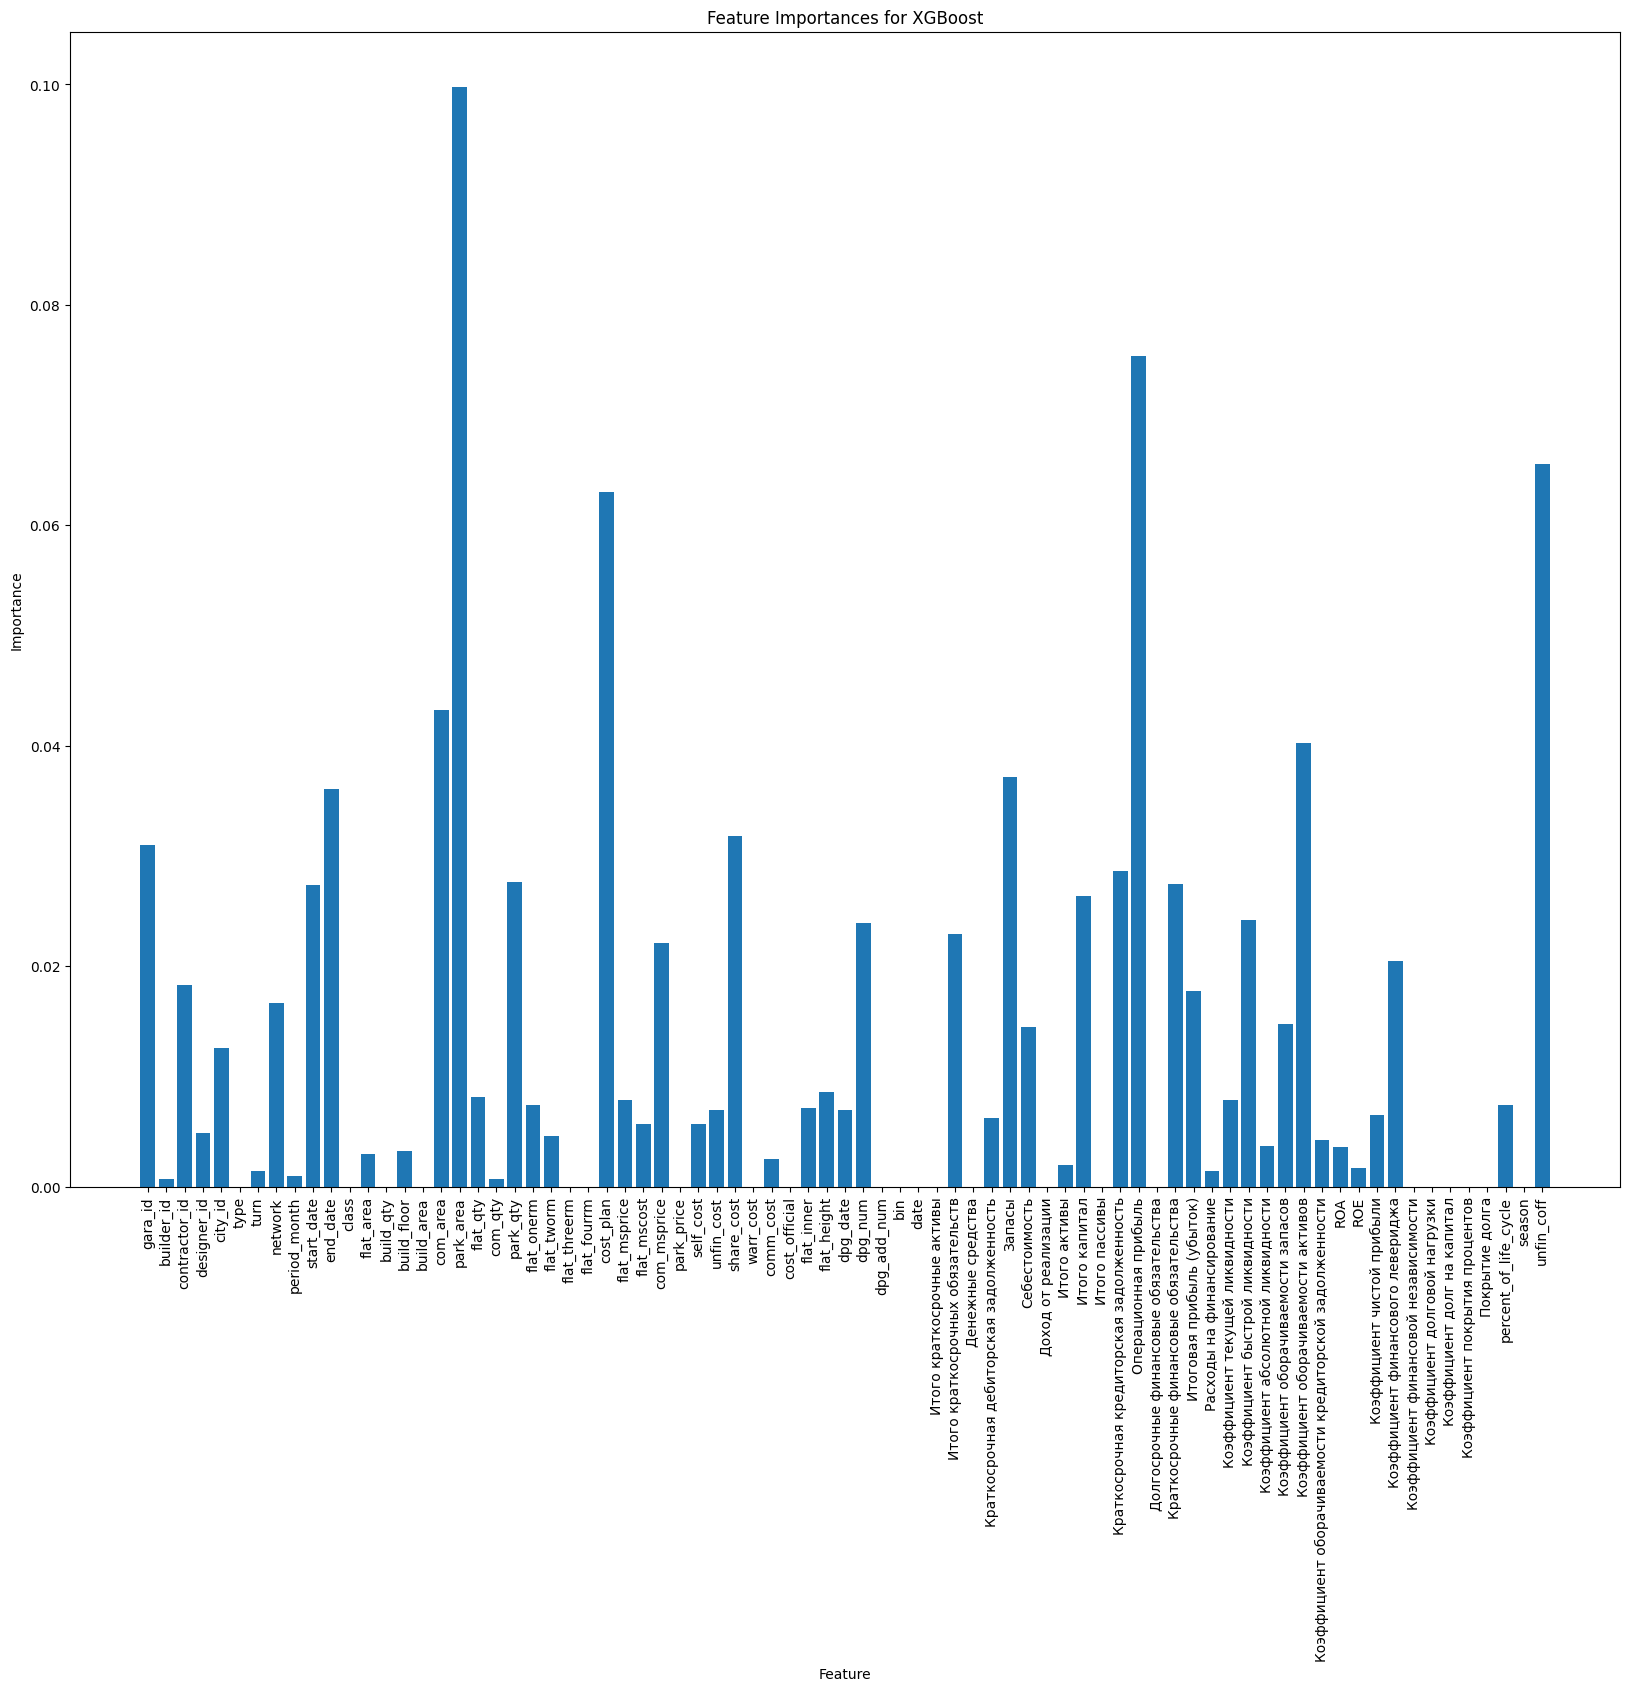

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from xgboost import XGBClassifier

X = df.drop(columns=['Target'])
y = df['Target']

imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.35, random_state=434)

models = {
    "SVM": svm.SVC(probability=True),
    "LogisticRegression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bagging": BaggingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

feature_importances = {}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, y_train)

    if hasattr(model, 'feature_importances_'):
        feature_importances[name] = model.feature_importances_

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(f"{name} Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}\n")
    print(f"{name} ROC AUC: {roc_auc_score(y_test, y_prob):.2f}\n")

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Various Models')
plt.legend()
plt.show()

for name, importance in feature_importances.items():
    plt.figure(figsize=(20, 15))
    plt.bar(range(len(importance)), importance)
    plt.title(f"Feature Importances for {name}")
    plt.xlabel("Feature")
    plt.ylabel("Importance")
    plt.xticks(range(len(importance)), X.columns, rotation=90)
    plt.show()

In [ ]:
df = df.drop(columns = {'application_name', 'author_id', 'engine_id', 'manager_id', 'status', 'decision_date', 'region_name', 'build_mscost', 'dpg_num_text', 'prolongation', 'update_date', 'state_id', 'create_date', 'annul_date', 'state_name', 'дата фин данных', 'life_cycle', 'today', 'real_life_cycle'})

## Neural Network

/usr/local/lib/python3.10/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.0     | val_0_auc: 0.62311 |  0:00:00s
epoch 1  | loss: 0.0     | val_0_auc: 0.62311 |  0:00:00s
epoch 2  | loss: 0.0     | val_0_auc: 0.62311 |  0:00:00s
epoch 3  | loss: 0.0     | val_0_auc: 0.62311 |  0:00:00s
epoch 4  | loss: 0.0     | val_0_auc: 0.62311 |  0:00:00s
epoch 5  | loss: 0.0     | val_0_auc: 0.62311 |  0:00:00s
epoch 6  | loss: 0.0     | val_0_auc: 0.62311 |  0:00:00s
epoch 7  | loss: 0.0     | val_0_auc: 0.62311 |  0:00:00s
epoch 8  | loss: 0.0     | val_0_auc: 0.62311 |  0:00:00s
epoch 9  | loss: 0.0     | val_0_auc: 0.62311 |  0:00:00s
epoch 10 | loss: 0.0     | val_0_auc: 0.62311 |  0:00:00s

Early stopping occurred at epoch 10 with best_epoch = 0 and best_val_0_auc = 0.62311
Test Accuracy: 0.43
ROC AUC Score: 0.62
Confusion Matrix:
[[25 41]
 [ 1  7]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.38      0.54        66
         1.0       0.15      0.88      0.25         8

    accurac

/usr/local/lib/python3.10/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


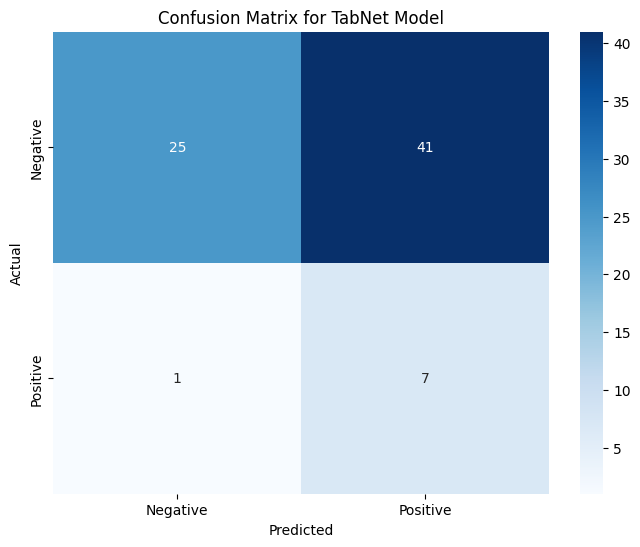

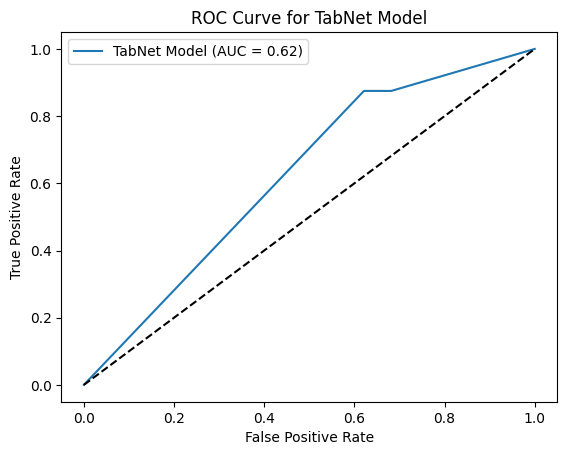

In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from pytorch_tabnet.tab_model import TabNetClassifier
import matplotlib.pyplot as plt
import seaborn as sns

X = df.drop(columns=['Target'])  
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=434)

X_train_np = X_train.values
X_test_np = X_test.values

y_train_np = y_train.reset_index(drop=True).values
y_test_np = y_test.reset_index(drop=True).values

if y_train_np.ndim > 1:
    y_train_np = y_train_np.ravel()
if y_test_np.ndim > 1:
    y_test_np = y_test_np.ravel()

tabnet_model = TabNetClassifier()
tabnet_model.fit(
    X_train_np, y_train_np,
    eval_set=[(X_test_np, y_test_np)],
    patience=10, max_epochs=100,
    batch_size=1024, virtual_batch_size=128
)

y_pred = tabnet_model.predict(X_test_np)
y_prob = tabnet_model.predict_proba(X_test_np)[:, 1]  #

accuracy = accuracy_score(y_test_np, y_pred)
roc_auc = roc_auc_score(y_test_np, y_prob)
print(f"Test Accuracy: {accuracy:.2f}")
print(f"ROC AUC Score: {roc_auc:.2f}")

conf_matrix = confusion_matrix(y_test_np, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test_np, y_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for TabNet Model")
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test_np, y_prob)
plt.plot(fpr, tpr, label=f"TabNet Model (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for TabNet Model')
plt.legend()
plt.show()

## Target 2